In [2]:
# importing all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# accessing the data in csv format

df=pd.read_csv("/Users/Mac/Documents/SUPER STORE/data/old_sales.csv")

In [4]:
df.shape
# (1000, 7)

df.info()

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Store Number     1000 non-null   int64  
 1   AreaStore        1000 non-null   int64  
 2   Property         1000 non-null   str    
 3   Type             1000 non-null   str    
 4   Old/New          1000 non-null   str    
 5   Checkout Number  921 non-null    float64
 6   Revenue          1000 non-null   str    
dtypes: float64(1), int64(2), str(4)
memory usage: 54.8 KB


,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue
0,1,1540,Owned,Extra,New,5.0,"3,42,09,500"
1,2,1790,Cooperate,Extra,Old,NaN,"2,09,82,000"
2,3,510,Owned,Express,New,4.0,"1,52,04,500"
3,4,470,Owned,Express,New,3.0,"78,19,500"
4,5,470,Rental,Express,New,NaN,"1,20,51,500"


In [5]:
# setting up the value of column areastore

df["AreaStore"]=df["AreaStore"].astype(str)
df["AreaStore"]=df["AreaStore"].str.split(".").str[0]

df["AreaStore"]=df["AreaStore"].astype(int)


df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Store Number     1000 non-null   int64  
 1   AreaStore        1000 non-null   int64  
 2   Property         1000 non-null   str    
 3   Type             1000 non-null   str    
 4   Old/New          1000 non-null   str    
 5   Checkout Number  921 non-null    float64
 6   Revenue          1000 non-null   str    
dtypes: float64(1), int64(2), str(4)
memory usage: 54.8 KB


In [6]:
# finding the outlier in checkout number column 

q1=df["Checkout Number"].quantile(0.25)
q3=df["Checkout Number"].quantile(0.75)

iqr=q3-q1


lower_limit=q1-(1.5*iqr)
upper_limit=q3+(1.5*iqr)

outliers=df[(df["Checkout Number"] <lower_limit) | (df["Checkout Number"] >upper_limit)]
print(outliers)


# there is no outlier in check out number column 

     Store Number  AreaStore   Property   Type Old/New  Checkout Number  \
130           131       3110     Rental  Hyper     New             14.0   
211           212       2200  Cooperate  Hyper     New             14.0   
262           263       3070      Owned  Hyper     New             14.0   
553           554       2860  Cooperate  Hyper     New             14.0   
864           865       3110  Cooperate  Hyper     New             14.0   

         Revenue  
130  3,00,93,000  
211  4,88,43,500  
262  4,43,38,000  
553  5,22,34,000  
864  5,36,08,500  


In [7]:
# filling null value with the mean 

df["Checkout Number"]=df["Checkout Number"].fillna(df["Checkout Number"].mean())
null=df["Checkout Number"].isnull().sum()


# converting the float into string to remove the extra zero after . 

df["Checkout Number"]=df["Checkout Number"].astype(str)

df["Checkout Number"]=df["Checkout Number"].str.split('.').str[0]

df["Checkout Number"]=df["Checkout Number"].astype(int)

null=df["Checkout Number"].isnull().sum()

df.info()

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Store Number     1000 non-null   int64
 1   AreaStore        1000 non-null   int64
 2   Property         1000 non-null   str  
 3   Type             1000 non-null   str  
 4   Old/New          1000 non-null   str  
 5   Checkout Number  1000 non-null   int64
 6   Revenue          1000 non-null   str  
dtypes: int64(3), str(4)
memory usage: 54.8 KB


,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue
0,1,1540,Owned,Extra,New,5,"3,42,09,500"
1,2,1790,Cooperate,Extra,Old,4,"2,09,82,000"
2,3,510,Owned,Express,New,4,"1,52,04,500"
3,4,470,Owned,Express,New,3,"78,19,500"
4,5,470,Rental,Express,New,4,"1,20,51,500"


In [8]:
# adjusting revenue column 

df["Revenue"]=df["Revenue"].str.replace(',','')

# finding the outliers in revenue column

df["Revenue"]=df["Revenue"].astype(int)


q1=df["Revenue"].quantile(0.25)
q3=df["Revenue"].quantile(0.75)

iqr=q3-q1

lower_limit=q1-(iqr*1.5)
upper_limit=q3+(iqr*1.5)

outlier=df[(df["Revenue"] <lower_limit) | (df["Revenue"]>upper_limit)]



In [9]:

# finding the outliers in AREA STORE column

q1=df["AreaStore"].quantile(0.25)
q3=df["AreaStore"].quantile(0.75)

iqr=q3-q1

lower_limit=q1-(iqr*1.5)
upper_limit=q3+(iqr*1.5)

outlier=df[(df["AreaStore"] <lower_limit) | (df["AreaStore"]>upper_limit)]
outlier

,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue
23,24,3940,Rental,Hyper,New,8,66329500
41,42,3780,Owned,Hyper,New,10,62079500
88,89,3870,Owned,Hyper,Old,7,55135500
97,98,4100,Cooperate,Hyper,Old,5,88919500
112,113,4450,Rental,Hyper,Old,6,21975500
146,147,3670,Owned,Hyper,New,10,73631500
163,164,3940,Rental,Hyper,New,13,41278500
168,169,4170,Owned,Hyper,New,11,46099500
215,216,4100,Rental,Hyper,New,7,26467000
225,226,4790,Owned,Hyper,Old,9,46537500


<Axes: xlabel='AreaStore', ylabel='Count'>

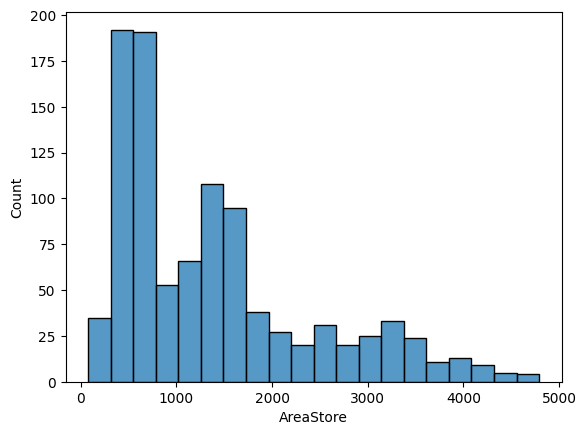

In [10]:
sns.histplot(df['AreaStore'])


<Axes: xlabel='Revenue', ylabel='Count'>

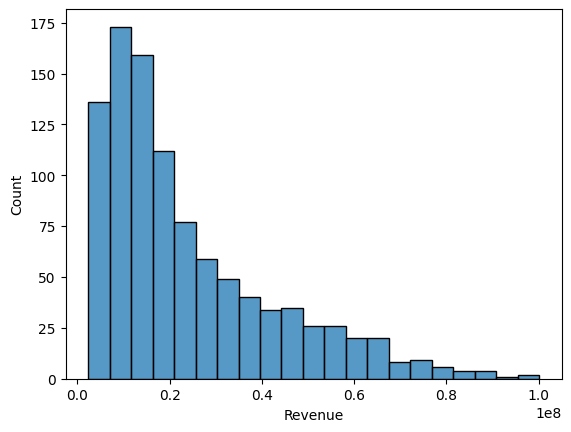

In [11]:
df['Property'].value_counts()

sns.histplot(df['Revenue'])



# 🏪 Store Count vs Revenue Analysis

## 📌 Key Insight

> **Inverse Relationship Observed:**
> Stores with **higher count** tend to generate **Low to Medium Revenue**,
> while stores with **lower count** tend to generate **High Revenue.**

---

## 🔍 Pattern Observed

| Store Count | Revenue Level | Example Property Types |
|-------------|--------------|------------------------|
| 🔴 High     | Low – Medium  | Corporate, Rental      |
| 🟢 Low      | High          | Owned, Rental/Corporate|

---

In [12]:
df['Property']=df['Property'].str.lower()

df['Property']=df['Property'].str.strip()

df['Property']=df['Property'].str.replace('cooperate','Corporate')

df.groupby('Property')['Revenue'].mean().sort_values().round(0)

df.groupby('Property')['Revenue'].sum()

df['Property'].value_counts()

Property
owned               376
rental              264
Corporate           239
rental/Corporate    121
Name: count, dtype: int64

# Property Category Analysis

---

## 1. Mean Average Revenue

| Property Type      | Avg Revenue  |
|--------------------|-------------|
| Corporate          | 2.31 Cr     |
| Rental             | 2.33 Cr     |
| Rental/Corporate   | 2.40 Cr     |
| Owned              | 2.49 Cr     |

---

## 2. Total Revenue

| Property Type      | Total Revenue (Cr) |
|--------------------|--------------------|
| Corporate          | 551.97 Cr          |
| Rental             | 616.02 Cr          |
| Rental/Corporate   | 290.85 Cr          |
| Owned              | 936.79 Cr          |

---

## 3. Store Count

| Property Type      | Count |
|--------------------|-------|
| Corporate          | 239   |
| Rental             | 264   |
| Rental/Corporate   | 121   |
| Owned              | 376   |

---

## 4. Key Insights

- Owned properties have the highest average revenue (2.49 Cr) and the most stores (376)
- Rental/Corporate has only 121 stores but average revenue (2.40 Cr) is stronger than Rental and Corporate
- Rental has good store count (264) but average revenue is low (2.33 Cr)
- Corporate has the lowest average revenue (2.31 Cr) despite having 239 stores

In [13]:

df['Old/New']=df['Old/New'].str.lower()
df['Old/New']=df['Old/New'].str.strip()


df['Old/New'].value_counts()

df.groupby('Old/New')['Revenue'].mean().sort_values().round(0)

# df.groupby('Old/New')['Revenue'].sum()



Old/New
new    23595655.0
old    26458163.0
Name: Revenue, dtype: float64

# Old vs New Property Analysis

---

## 1. Store Count

| Type | Count |
|------|-------|
| New  | 874   |
| Old  | 126   |

---

## 2. Mean Average Revenue

| Type | Avg Revenue |
|------|-------------|
| New  | 2.36 Cr     |
| Old  | 2.65 Cr     |

---

## 3. Total Revenue

| Type | Total Revenue (Cr) |
|------|--------------------|
| New  | 2062.26 Cr         |
| Old  | 333.37 Cr          |

---

## 4. Insights

- New properties have far more stores (874 vs 126)
- Old properties have higher average revenue per store (2.65 Cr vs 2.36 Cr)
- New properties lead in total revenue (2062 Cr) simply because of higher count
- Old properties perform better individually but there are very few of them


In [14]:
df.groupby('Checkout Number')['Revenue'].mean().sort_values().round(0)


Checkout Number
1     11492737.0
2     12337479.0
3     12966053.0
4     20892103.0
5     26824172.0
6     30583970.0
7     32068738.0
13    37609500.0
8     39109290.0
9     42150988.0
12    43708188.0
14    45823400.0
11    47431476.0
10    52374382.0
Name: Revenue, dtype: float64

In [15]:
# Kya zyada checkout counters se revenue increase hota hai ya bas cost badhta hai?
# 👉 Insight:
# Checkout Number vs Revenue


# Checkout Number
# 1     11492737.0
# 2     12337479.0
# 3     12966053.0
# 4     20892103.0
# 5     26824172.0
# 6     30583970.0
# 7     32068738.0
# 13    37609500.0
# 8     39109290.0
# 9     42150988.0
# 12    43708188.0
# 14    45823400.0
# 11    47431476.0
# 10    52374382.0


# Insight:

# More checkout counters = More revenue!

# Checkout Counters vs Revenue Analysis

---

## Mean Revenue by Checkout Count

| Checkout Counters | Avg Revenue (Cr) |
|-------------------|-----------------|
| 1                 | 1.15 Cr         |
| 2                 | 1.23 Cr         |
| 3                 | 1.30 Cr         |
| 4                 | 2.09 Cr         |
| 5                 | 2.68 Cr         |
| 6                 | 3.06 Cr         |
| 7                 | 3.21 Cr         |
| 8                 | 3.91 Cr         |
| 9                 | 4.22 Cr         |
| 10                | 5.24 Cr         |
| 11                | 4.74 Cr         |
| 12                | 4.37 Cr         |
| 13                | 3.76 Cr         |
| 14                | 4.58 Cr         |

---

## Pattern

| Range            | Observation                        |
|------------------|------------------------------------|
| 1 to 5 counters  | Low revenue, slow growth           |
| 5 to 10 counters | Revenue rises sharply              |
| 10 to 14 counters| Revenue is high but starts to vary |

---

## Insights

- Clear trend: more checkout counters, higher average revenue
- 1 counter store: 1.15 Cr avg vs 10 counter store: 5.24 Cr avg — almost 4.5x difference
- Counters reflect store size — larger stores have more customers and more revenue
- Revenue peaks at 10 counters (5.24 Cr), after which there is some fluctuation

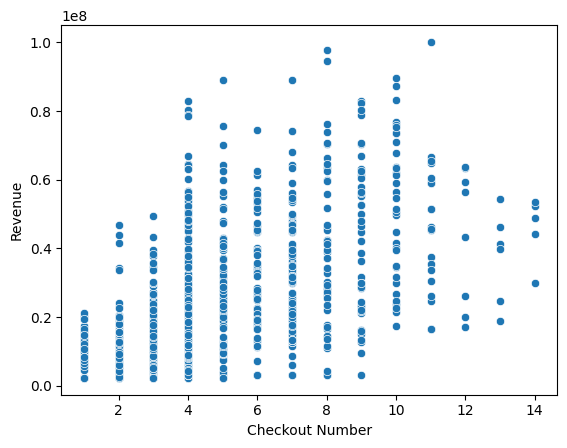

In [16]:
# 🚀 Advanced Level Problem (Interview type)
# 👉 “Same area ke stores mein revenue difference kyun hai?”
# Isme tu:
# Area same
# But revenue different
# 👉 Root cause:
# Checkout kam?
# Property type?
# Old vs New?
df.head()
sns.scatterplot(x='Checkout Number', y='Revenue', data=df)
plt.show()


## Business Problem
Why is there a revenue difference between stores despite having similar store size?

## Key Insights

1. Hyper stores generate higher revenue due to higher product variety and footfall.
2. Stores with more checkout counters handle more customers, increasing revenue.
3. Older stores tend to have more consistent revenue due to customer loyalty.
4. Revenue per sq.ft shows operational efficiency differences.


## Recommendations

- Increase checkout counters to reduce waiting time
- Improve product variety in low-performing stores
- Support new stores with promotions to build awareness
- Focus on improving revenue per sq.ft efficiency

In [18]:
df.groupby('Property')['Revenue'].max()

Property
Corporate           100083000
owned                97853000
rental               94511500
rental/Corporate     89138000
Name: Revenue, dtype: int64